In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 무시 설정
import warnings
warnings.filterwarnings(action='ignore')

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

### [데이터 로드]

In [2]:
weather = pd.read_csv('./전남_일별_기상청_데이터_최종수정.csv')
weather.head()

,지점,지점명,일시,평균기온(°C),최저기온(°C),최고기온(°C),일강수량(mm),평균 풍속(m/s),평균 이슬점온도(°C),평균 상대습도(%),합계 일조시간(hr)
0,165,목포,2014-05-01,15.4,10.6,20.3,0.0,1.6,12.0,82.5,12.2
1,165,목포,2014-05-02,15.6,12.0,23.3,0.0,4.4,13.6,88.5,7.3
2,165,목포,2014-05-03,13.4,10.0,19.3,0.0,5.6,9.2,77.5,12.2
3,165,목포,2014-05-04,13.6,9.6,20.0,1.0,3.9,9.3,78.9,3.0
4,165,목포,2014-05-05,12.6,8.7,17.3,0.0,4.2,4.6,60.0,12.1


In [3]:
weather['일시'] = pd.to_datetime(weather['일시'])

weather['year'] = weather['일시'].dt.year
weather['month'] = weather['일시'].dt.month
weather['day'] = weather['일시'].dt.day

weather.drop('일시', axis=1, inplace=True)

weather.head()

,지점,지점명,평균기온(°C),최저기온(°C),최고기온(°C),일강수량(mm),평균 풍속(m/s),평균 이슬점온도(°C),평균 상대습도(%),합계 일조시간(hr),year,month,day
0,165,목포,15.4,10.6,20.3,0.0,1.6,12.0,82.5,12.2,2014,5,1
1,165,목포,15.6,12.0,23.3,0.0,4.4,13.6,88.5,7.3,2014,5,2
2,165,목포,13.4,10.0,19.3,0.0,5.6,9.2,77.5,12.2,2014,5,3
3,165,목포,13.6,9.6,20.0,1.0,3.9,9.3,78.9,3.0,2014,5,4
4,165,목포,12.6,8.7,17.3,0.0,4.2,4.6,60.0,12.1,2014,5,5


In [4]:
rice = pd.read_csv('./통합_논벼_예찰결과_피해율유지.csv')
rice.head()

,조사일,지역,이삭도열병,흰잎마름병,세균벼알마름병,깨씨무늬병,벼멸구,흰등멸구,혹명나방,먹노린재,...,벼줄기굴파리,애멸구,끝동매미충,벼물바구미,멸강나방,이화명나방1화기,벼검은줄오갈병,오갈병,이삭누룩병,이화명나방2화기
0,2014.09.16,강진군,0.070,0.14,0.020,0.00,0.000,1.11,0.0,0.28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014.09.16,고흥군,0.009,0.00,0.000,0.11,0.071,0.00,0.0,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014.09.16,곡성군,0.080,0.00,0.000,0.17,0.000,0.00,0.0,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014.09.16,광양시,0.000,0.00,0.043,0.01,0.000,0.00,0.0,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014.09.16,구례군,0.000,0.00,0.000,0.00,0.000,0.00,0.0,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
rice['조사일'] = pd.to_datetime(rice['조사일'])

rice['year'] = rice['조사일'].dt.year
rice['month'] = rice['조사일'].dt.month
rice['day'] = rice['조사일'].dt.day

rice.drop('조사일', axis=1, inplace=True)

rice.head()

,지역,이삭도열병,흰잎마름병,세균벼알마름병,깨씨무늬병,벼멸구,흰등멸구,혹명나방,먹노린재,잎도열병,...,벼물바구미,멸강나방,이화명나방1화기,벼검은줄오갈병,오갈병,이삭누룩병,이화명나방2화기,year,month,day
0,강진군,0.070,0.14,0.020,0.00,0.000,1.11,0.0,0.28,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014,9,16
1,고흥군,0.009,0.00,0.000,0.11,0.071,0.00,0.0,0.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014,9,16
2,곡성군,0.080,0.00,0.000,0.17,0.000,0.00,0.0,0.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014,9,16
3,광양시,0.000,0.00,0.043,0.01,0.000,0.00,0.0,0.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014,9,16
4,구례군,0.000,0.00,0.000,0.00,0.000,0.00,0.0,0.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014,9,16


### 최댓값, 최솟값, 평균

In [6]:
max_values = rice.iloc[:, 1:24].max()
max_values

이삭도열병        1.720
흰잎마름병        0.860
세균벼알마름병      1.117
깨씨무늬병        7.860
벼멸구          4.000
흰등멸구         7.810
혹명나방         3.280
먹노린재        23.939
잎도열병         0.491
잎집무늬마름병     12.190
줄무늬잎마름병      0.067
벼잎벌레         0.330
벼애잎굴파리       0.590
벼줄기굴파리       0.606
애멸구          3.440
끝동매미충        0.748
벼물바구미        5.576
멸강나방         0.178
이화명나방1화기     0.412
벼검은줄오갈병      0.000
오갈병          0.000
이삭누룩병        0.154
이화명나방2화기     0.994
dtype: float64

In [21]:
import pandas as pd
import numpy as np

df = rice.iloc[:, 1:24]

# 1. 수치형 컬럼만 선택
numeric_df = df.select_dtypes(include=['number'])

# 2. 0을 NaN으로 치환 후 최소값 계산 (NaN은 min 계산에서 자동으로 제외됨)
min_values = numeric_df.replace(0, np.nan).min()

# 3. 결과 출력
print("--- 컬럼별 0을 제외한 최소값 ---")
min_values

--- 컬럼별 0을 제외한 최소값 ---


이삭도열병       0.001
흰잎마름병       0.001
세균벼알마름병     0.001
깨씨무늬병       0.001
벼멸구         0.001
흰등멸구        0.001
혹명나방        0.001
먹노린재        0.001
잎도열병        0.001
잎집무늬마름병     0.001
줄무늬잎마름병     0.001
벼잎벌레        0.001
벼애잎굴파리      0.001
벼줄기굴파리      0.001
애멸구         0.001
끝동매미충       0.001
벼물바구미       0.001
멸강나방        0.001
이화명나방1화기    0.001
벼검은줄오갈병       NaN
오갈병           NaN
이삭누룩병       0.001
이화명나방2화기    0.001
dtype: float64

In [26]:
import pandas as pd
import numpy as np

df = rice.iloc[:, 1:24]

# 2. 수치형 컬럼만 선택
numeric_df = df.select_dtypes(include=[np.number])

# 3. 0을 NaN으로 변환 후 평균 계산
# NaN은 mean() 함수에서 자동으로 제외되므로 0이 아닌 값들만 계산됩니다.
mean_excluding_zero = numeric_df.replace(0, np.nan).mean()

# 4. 결과 보기 좋게 출력
result = mean_excluding_zero.reset_index()
result.columns = ['병해충 명칭', '평균 피해율']
result

,병해충 명칭,평균 피해율
0,이삭도열병,0.048165
1,흰잎마름병,0.052802
2,세균벼알마름병,0.028562
3,깨씨무늬병,0.121478
4,벼멸구,0.210928
5,흰등멸구,0.226552
6,혹명나방,0.136222
7,먹노린재,0.248674
8,잎도열병,0.008978
9,잎집무늬마름병,0.227952


In [31]:
import pandas as pd

# 1. 각 변수가 Series 형태인지 확인하고 딕셔너리로 묶습니다.
# 만약 'result'가 데이터프레임이라면, '유효 데이터 평균(0 제외)' 컬럼만 시리즈로 추출해서 넣어야 합니다.
data_dict = {
    '최소값(0제외)': min_values,
    '최대값': max_values,
}

# 'result' 변수가 데이터프레임 형태인 경우 처리 (스크린샷 기준)
if isinstance(result, pd.DataFrame):
    # '병해충 컬럼'을 인덱스로 만들어서 다른 데이터와 행을 맞춥니다.
    temp_result = result.set_index('병해충 명칭')['평균 피해율']
    data_dict['평균값(0제외)'] = temp_result
else:
    data_dict['평균값(0제외)'] = result

# 2. 데이터프레임 생성
summary_df = pd.DataFrame(data_dict)

# 3. 인덱스(병해충명)를 컬럼으로 변환
summary_df = summary_df.reset_index()
summary_df.rename(columns={'index': '병해충명'}, inplace=True)

# 4. CSV 저장 (한글 깨짐 방지)
output_file = '병해충_통계_요약_리포트.csv'
summary_df.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"✅ 성공적으로 '{output_file}' 파일이 생성되었습니다.")
summary_df.head()

PermissionError: [Errno 13] Permission denied: '병해충_통계_요약_리포트.csv'

In [32]:
summary_df

,병해충명,최소값(0제외),최대값,평균값(0제외)
0,이삭도열병,0.001,1.720,0.048165
1,흰잎마름병,0.001,0.860,0.052802
2,세균벼알마름병,0.001,1.117,0.028562
3,깨씨무늬병,0.001,7.860,0.121478
4,벼멸구,0.001,4.000,0.210928
5,흰등멸구,0.001,7.810,0.226552
6,혹명나방,0.001,3.280,0.136222
7,먹노린재,0.001,23.939,0.248674
8,잎도열병,0.001,0.491,0.008978
9,잎집무늬마름병,0.001,12.190,0.227952


### 데이터 개수 및 비율 확인

In [8]:
count_df = ((rice.iloc[:, 1:24].notnull()) & (rice.iloc[:, 1:24] != 0)).sum()

print("--- 컬럼별 0과 NaN을 제외한 데이터 개수 ---")
print(count_df)

--- 컬럼별 0과 NaN을 제외한 데이터 개수 ---
이삭도열병        91
흰잎마름병       172
세균벼알마름병     105
깨씨무늬병       370
벼멸구         194
흰등멸구        466
혹명나방        567
먹노린재        536
잎도열병        135
잎집무늬마름병     777
줄무늬잎마름병      26
벼잎벌레         32
벼애잎굴파리       61
벼줄기굴파리       52
애멸구         141
끝동매미충       123
벼물바구미       305
멸강나방         13
이화명나방1화기     68
벼검은줄오갈병       0
오갈병           0
이삭누룩병        19
이화명나방2화기     65
dtype: int64


In [9]:
column_counts = rice.iloc[:, 1:24].count()

print("--- 컬럼별 데이터 개수 (NaN 제외, 0 포함) ---")
print(column_counts)

--- 컬럼별 데이터 개수 (NaN 제외, 0 포함) ---
이삭도열병        829
흰잎마름병        826
세균벼알마름병      827
깨씨무늬병       1704
벼멸구         1682
흰등멸구        1695
혹명나방        1734
먹노린재        1749
잎도열병        1678
잎집무늬마름병     1717
줄무늬잎마름병     1671
벼잎벌레        1666
벼애잎굴파리      1668
벼줄기굴파리      1670
애멸구         1668
끝동매미충       1667
벼물바구미       1717
멸강나방        1694
이화명나방1화기    1694
벼검은줄오갈병      808
오갈병          808
이삭누룩병        808
이화명나방2화기     808
dtype: int64


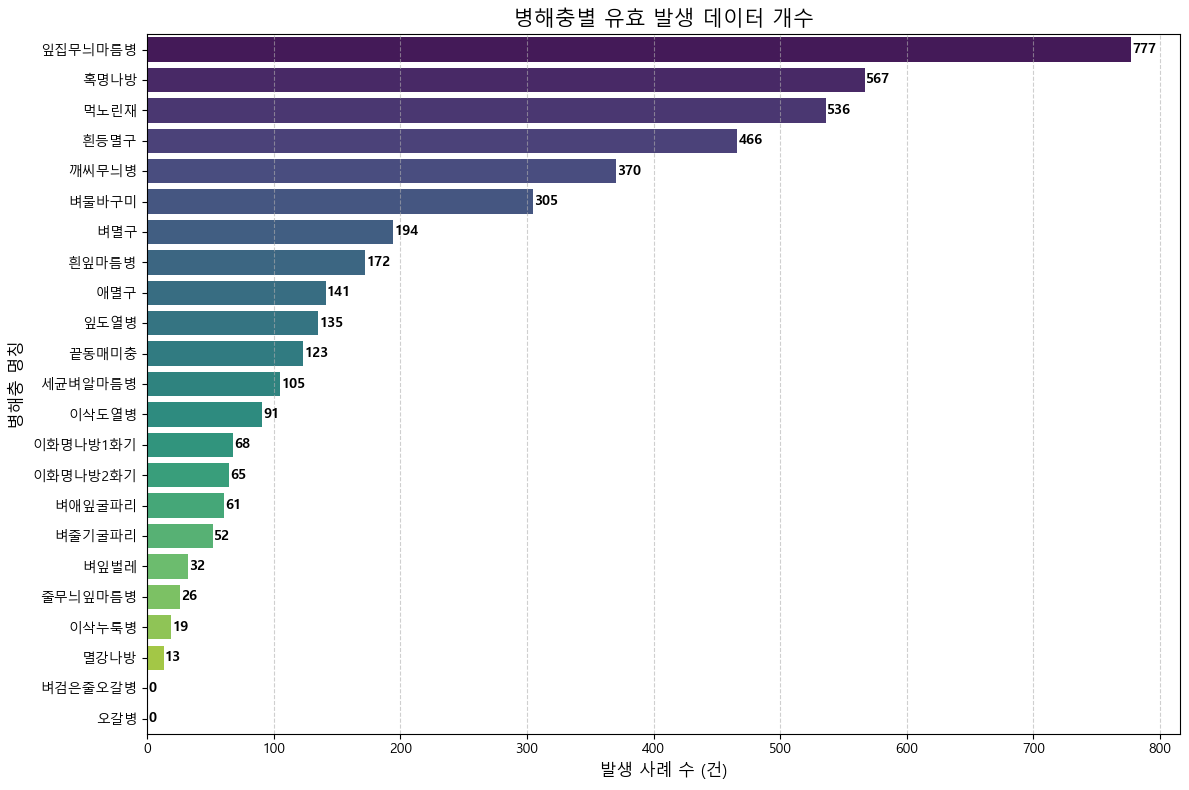

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 한글 폰트 설정
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 가공 (0과 NaN 제외 개수 계산)
# 수치형 컬럼만 선택 (조사일, 지역 제외)
numeric_df = rice.iloc[:, 1:24] 
valid_counts = ((numeric_df.notnull()) & (numeric_df != 0)).sum().sort_values(ascending=False)

# 3. 그래프 그리기
plt.figure(figsize=(12, 8))
sns.barplot(x=valid_counts.values, y=valid_counts.index, palette='viridis')

# 그래프 꾸미기
plt.title('병해충별 유효 발생 데이터 개수', fontsize=15)
plt.xlabel('발생 사례 수 (건)', fontsize=12)
plt.ylabel('병해충 명칭', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# 막대 끝에 숫자 표시
for i, v in enumerate(valid_counts.values):
    plt.text(v + 1, i, str(int(v)), color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

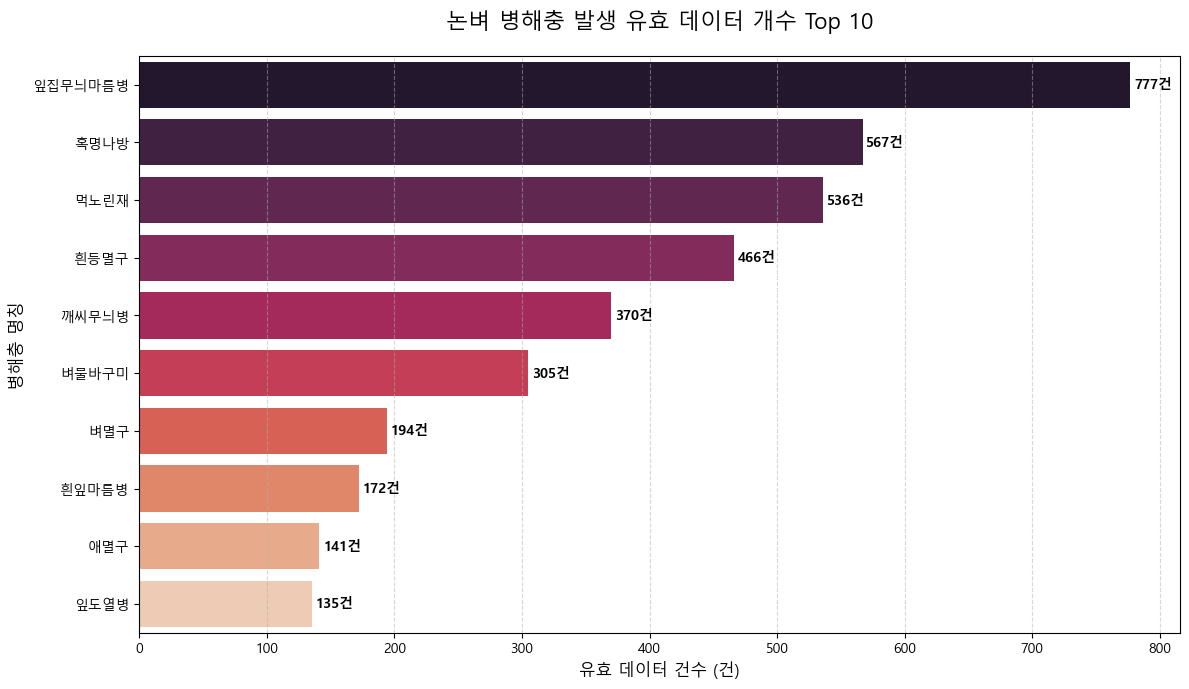

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = rice.iloc[:, 1:24]

# 1. 한글 폰트 설정 (윈도우: Malgun Gothic, 맥: AppleGothic)
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False

# 2. 유효 데이터(0과 NaN 제외) 개수 계산
# 수치형 컬럼만 추출 (조사일, 지역 제외)
numeric_cols = df.select_dtypes(include=['number']).columns
valid_counts = ((df[numeric_cols].notnull()) & (df[numeric_cols] != 0)).sum()

# 3. 상위 10개 추출
top10_pest = valid_counts.sort_values(ascending=False).head(10)

# 4. 그래프 그리기
plt.figure(figsize=(12, 7))
# 색상을 다양하게 주기 위해 'rocket' 팔레트 사용
ax = sns.barplot(x=top10_pest.values, y=top10_pest.index, palette='rocket')

# 그래프 디테일 설정
plt.title('논벼 병해충 발생 유효 데이터 개수 Top 10', fontsize=16, pad=20)
plt.xlabel('유효 데이터 건수 (건)', fontsize=12)
plt.ylabel('병해충 명칭', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# 막대 끝에 실제 수치 표시
for i, v in enumerate(top10_pest.values):
    ax.text(v + 3, i, f'{int(v)}건', color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

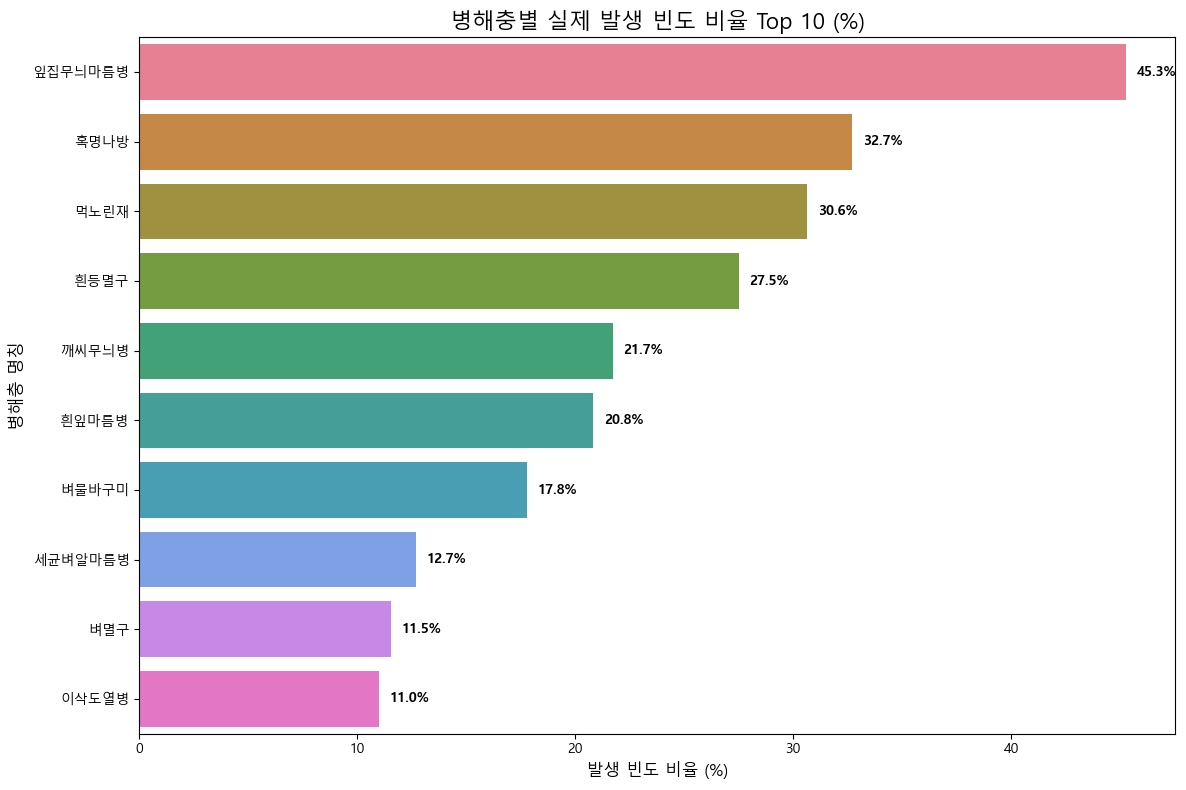

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 수치형 컬럼만 확실하게 선택 (핵심!)
# '조사일', '지역' 등 문자열 컬럼은 자동으로 제외됩니다.
numeric_df = rice.iloc[:, 1:24].select_dtypes(include=['number'])

# 2. 비율 계산 (모든 값이 0인 경우 발생할 수 있는 nan 방지를 위해 0 초과 조건 적용)
# numeric_df.count(): NaN을 제외한 전체 조사 건수
# (numeric_df > 0).sum(): 그 중 0보다 큰(발생한) 건수
occurrence_rate = ((numeric_df > 0).sum() / numeric_df.count()) * 100

# 3. 내림차순 정렬 및 상위 10개 추출
occurrence_rate = occurrence_rate.sort_values(ascending=False).head(10)

# 4. 그래프 시각화
plt.figure(figsize=(12, 8))
# top 10의 인덱스(병해충 이름)와 값(비율)을 전달
ax = sns.barplot(x=occurrence_rate.values, y=occurrence_rate.index, palette='husl')

# 막대 끝에 비율(%) 표시
for i, v in enumerate(occurrence_rate.values):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.title('병해충별 실제 발생 빈도 비율 Top 10 (%)', fontsize=16)
plt.xlabel('발생 빈도 비율 (%)', fontsize=12)
plt.ylabel('병해충 명칭', fontsize=12)
plt.tight_layout()
plt.show()

### [멸강나방] 유효 데이터 확인

In [30]:
import pandas as pd

# 1. 데이터 로드
df = pd.read_csv('통합_논벼_예찰결과_피해율유지.csv')

# 2. 멸강나방 컬럼명 설정 (공백 포함 주의)
col_name = '멸강나방'

# 3. 유효 데이터 필터링 (NaN이 아니고 0도 아닌 데이터)
valid_armyworm = df[df[col_name].notnull() & (df[col_name] != 0)]

# 4. 결과 출력 (조사일, 지역, 멸강나방 피해율만 보기)
print(f"--- 멸강나방 유효 데이터 (총 {len(valid_armyworm)}건) ---")
print(valid_armyworm[['조사일', '지역', col_name]])

# 5. 기초 통계 확인
print("\n--- 멸강나방 피해율 요약 ---")
print(valid_armyworm[col_name].describe())

--- 멸강나방 유효 데이터 (총 13건) ---
             조사일   지역   멸강나방
76    2015.07.16  영암군  0.020
192   2016.07.16  광양시  0.047
320   2017.06.16  나주시  0.002
367   2017.07.16  신안군  0.020
735   2019.08.16  여수시  0.056
760   2019.09.01  진도군  0.003
864   2020.07.16  해남군  0.002
1216  2022.08.16  담양군  0.001
1376  2023.08.16  무안군  0.001
1416  2023.09.16  나주시  0.075
1417  2023.09.16  담양군  0.001
1502  2024.07.16  영암군  0.002
1581  2024.09.16  보성군  0.178

--- 멸강나방 피해율 요약 ---
count    13.000000
mean      0.031385
std       0.050558
min       0.001000
25%       0.002000
50%       0.003000
75%       0.047000
max       0.178000
Name: 멸강나방, dtype: float64
